# Phase 5: Explainability and Calibration

Generate Grad-CAM heatmaps, MC-dropout uncertainty estimates, and calibration diagnostics for the EfficientNet-B0 model.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import random
import sys

import numpy as np
import pandas as pd
import torch
import yaml
from torch.utils.data import DataLoader

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.dataset import Ham10000Dataset, build_image_index
from src.explainability.gradcam import GradCAM
from src.explainability.uncertainty import mc_dropout_predict
from src.models.efficientnet import MelanomaClassifier
from src.preprocessing.augmentation import get_val_transforms
from src.training.calibration import TemperatureScaling

artifact_dir = project_root / "reports" / "artifacts"
figure_dir = project_root / "reports" / "figures"
artifact_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(json.dumps({
    "project_root": str(project_root),
    "device": str(device),
}, indent=2))

/home/selba/Desktop/ENSIAS/Mlops/PFA/code/.venv/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


{
  "project_root": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code",
  "device": "cuda"
}


In [4]:
config_path = project_root / "configs" / "training" / "efficientnet_b0.yaml"
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))
set_seed(int(config.get("seed", 42)))

model_cfg = config.get("model", {})
model = MelanomaClassifier(
    model_name=model_cfg.get("name", "efficientnet_b0"),
    num_classes=int(model_cfg.get("num_classes", 2)),
    pretrained=bool(model_cfg.get("pretrained", True)),
    dropout_rate=float(model_cfg.get("dropout_rate", 0.3)),
)

run_summary_path = artifact_dir / "training_full_run_summary.json"
run_id = None
if run_summary_path.exists():
    run_id = json.loads(run_summary_path.read_text(encoding="utf-8")).get("run_id")

checkpoint_candidates = []
if run_id is not None:
    mlflow_root = project_root / "mlflow"
    if mlflow_root.exists():
        for path in mlflow_root.rglob("best_model.pt"):
            if run_id in str(path):
                checkpoint_candidates.append(path)
checkpoint_candidates.extend([
    project_root / "models" / "checkpoints" / "best_model.pt",
    project_root / "notebooks" / "models" / "checkpoints" / "best_model.pt",
])

checkpoint_path = next((path for path in checkpoint_candidates if path.exists()), None)
if checkpoint_path is None:
    tried = ", ".join(str(path) for path in checkpoint_candidates)
    raise FileNotFoundError(f"Missing checkpoint. Tried: {tried}")
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print(json.dumps({
    "checkpoint_path": str(checkpoint_path),
    "run_id": run_id or checkpoint.get("run_id"),
}, indent=2))

{
  "checkpoint_path": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/mlflow/323210160227859698/9c74ae3a097a4f2f968767c0882c9262/artifacts/best_model.pt",
  "run_id": "9c74ae3a097a4f2f968767c0882c9262"
}


In [5]:
data_root = project_root / "data"
test_df = pd.read_csv(data_root / "splits" / "test_split.csv")
val_df = pd.read_csv(data_root / "splits" / "val_split.csv")

def ensure_label(df: pd.DataFrame) -> pd.DataFrame:
    if "label" in df.columns:
        return df
    df = df.copy()
    df["label"] = (df["dx"] == "mel").astype(int)
    return df

test_df = ensure_label(test_df)
val_df = ensure_label(val_df)

image_index = build_image_index(data_root / "raw")
val_transforms = get_val_transforms()

test_dataset = Ham10000Dataset(test_df, image_index, transforms=val_transforms)
val_dataset = Ham10000Dataset(val_df, image_index, transforms=val_transforms)

summary = {
    "test_size": int(len(test_df)),
    "val_size": int(len(val_df)),
    "test_class_counts": test_df["label"].value_counts().sort_index().to_dict(),
    "val_class_counts": val_df["label"].value_counts().sort_index().to_dict(),
}
print(json.dumps(summary, indent=2))
summary

{
  "test_size": 1541,
  "val_size": 1484,
  "test_class_counts": {
    "0": 1366,
    "1": 175
  },
  "val_class_counts": {
    "0": 1317,
    "1": 167
  }
}


{'test_size': 1541,
 'val_size': 1484,
 'test_class_counts': {0: 1366, 1: 175},
 'val_class_counts': {0: 1317, 1: 167}}

Saved Grad-CAM grid to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/gradcam_samples.png
Saved Grad-CAM summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/gradcam_summary.json


[{'image_id': 'ISIC_0025175',
  'label': 0,
  'predicted_class': 0,
  'confidence': 1.0,
  'target_layer': 'backbone.conv_head'},
 {'image_id': 'ISIC_0026599',
  'label': 0,
  'predicted_class': 0,
  'confidence': 0.7879526019096375,
  'target_layer': 'backbone.conv_head'},
 {'image_id': 'ISIC_0026377',
  'label': 0,
  'predicted_class': 0,
  'confidence': 1.0,
  'target_layer': 'backbone.conv_head'}]

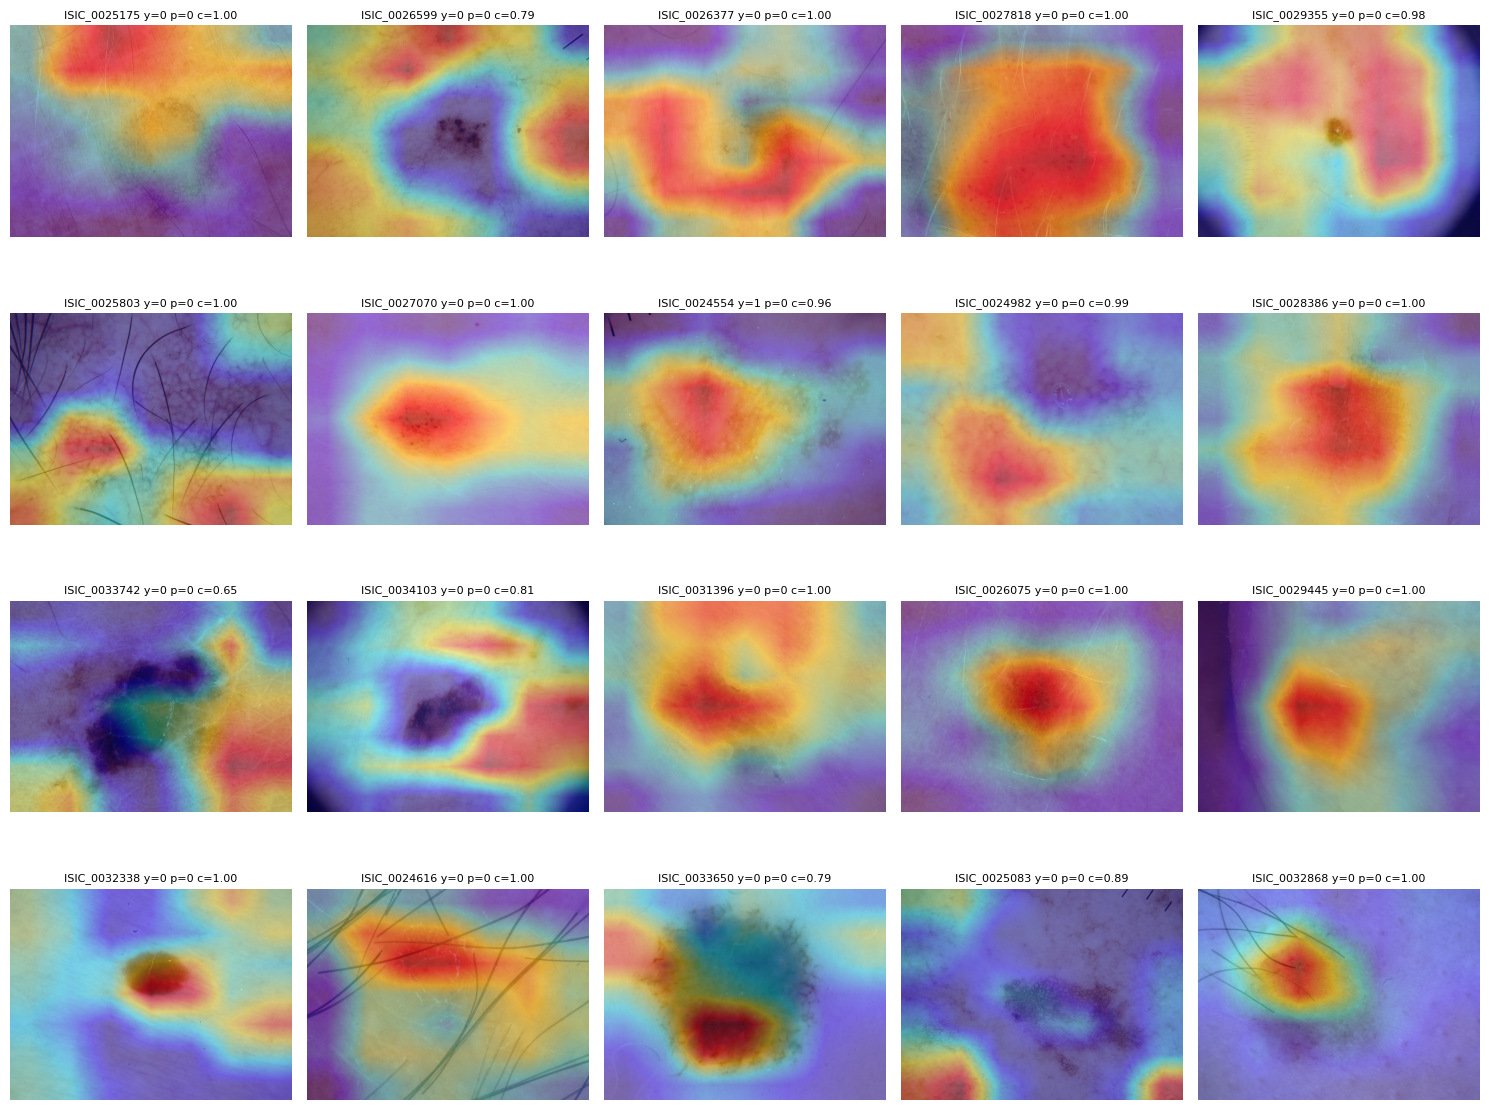

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

def find_last_conv_layer_name(model: torch.nn.Module) -> str | None:
    conv_layers = [
        name
        for name, module in model.named_modules()
        if isinstance(module, torch.nn.Conv2d)
    ]
    return conv_layers[-1] if conv_layers else None

target_layer_name = "backbone.conv_head"
if target_layer_name not in dict(model.named_modules()):
    target_layer_name = find_last_conv_layer_name(model)
if target_layer_name is None:
    raise RuntimeError("No conv layer found for Grad-CAM.")

gradcam = GradCAM(model, target_layer_name)

sample_df = test_df.sample(n=min(20, len(test_df)), random_state=7).reset_index(drop=True)
rows = []
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    image_id = row["image_id"]
    label = int(row["label"])
    image_path = image_index[image_id]
    original = np.array(Image.open(image_path).convert("RGB"))
    input_tensor = val_transforms(image=original)["image"]
    heatmap, pred_class, confidence = gradcam.generate(input_tensor)
    overlay = gradcam.overlay_on_image(original, heatmap, alpha=0.4)
    ax.imshow(overlay)
    ax.set_title(f"{image_id} y={label} p={pred_class} c={confidence:.2f}", fontsize=8)
    ax.axis("off")
    rows.append({
        "image_id": image_id,
        "label": label,
        "predicted_class": int(pred_class),
        "confidence": float(confidence),
        "target_layer": target_layer_name,
    })

for ax in axes[len(rows):]:
    ax.axis("off")

fig.tight_layout()
gradcam_path = figure_dir / "gradcam_samples.png"
fig.savefig(gradcam_path, dpi=160, bbox_inches="tight")

summary_path = artifact_dir / "gradcam_summary.json"
summary_path.write_text(json.dumps(rows, indent=2), encoding="utf-8")

print(f"Saved Grad-CAM grid to {gradcam_path}")
print(f"Saved Grad-CAM summary to {summary_path}")
rows[:3]

Saved uncertainty summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/uncertainty_summary.csv
Saved uncertainty plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/uncertainty_distributions.png


,mean_probs,std_probs,predictive_entropy,mutual_information,melanoma_probability,uncertainty,is_uncertain,image_id,label
0,"[0.43022788, 0.5697721]","[0.332707, 0.332707]",0.683379,0.265156,0.569772,0.332707,True,ISIC_0033680,0
1,"[0.82099754, 0.17900245]","[0.24364296, 0.24364294]",0.469877,0.189335,0.179002,0.243643,True,ISIC_0033427,0
2,"[0.94511735, 0.05488252]","[0.13741684, 0.13741684]",0.212648,0.105925,0.054883,0.137417,False,ISIC_0032337,0
3,"[0.19672056, 0.8032796]","[0.2883656, 0.2883656]",0.495822,0.243874,0.803280,0.288366,True,ISIC_0032967,0
4,"[0.74770755, 0.25229245]","[0.27578893, 0.27578893]",0.564840,0.212610,0.252292,0.275789,True,ISIC_0026494,0


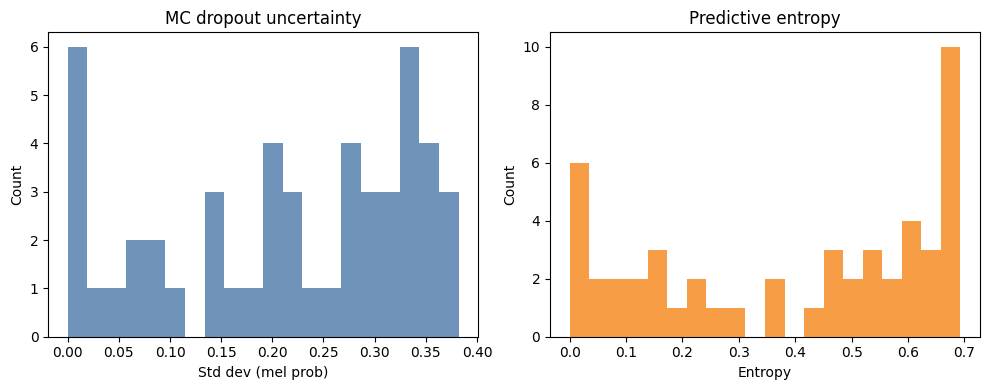

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

sample_uncertainty = test_df.sample(n=min(50, len(test_df)), random_state=13).reset_index(drop=True)
uncertainty_rows = []

for _, row in sample_uncertainty.iterrows():
    image_id = row["image_id"]
    label = int(row["label"])
    image_path = image_index[image_id]
    original = np.array(Image.open(image_path).convert("RGB"))
    input_tensor = val_transforms(image=original)["image"]
    result = mc_dropout_predict(model, input_tensor, n_passes=30, device=str(device))
    result.update({"image_id": image_id, "label": label})
    uncertainty_rows.append(result)

uncertainty_df = pd.DataFrame(uncertainty_rows)
uncertainty_path = artifact_dir / "uncertainty_summary.csv"
uncertainty_df.to_csv(uncertainty_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(uncertainty_df["uncertainty"], bins=20, color="#4c78a8", alpha=0.8)
axes[0].set_title("MC dropout uncertainty")
axes[0].set_xlabel("Std dev (mel prob)")
axes[0].set_ylabel("Count")

axes[1].hist(uncertainty_df["predictive_entropy"], bins=20, color="#f58518", alpha=0.8)
axes[1].set_title("Predictive entropy")
axes[1].set_xlabel("Entropy")
axes[1].set_ylabel("Count")

fig.tight_layout()
uncertainty_plot_path = figure_dir / "uncertainty_distributions.png"
fig.savefig(uncertainty_plot_path, dpi=160, bbox_inches="tight")

print(f"Saved uncertainty summary to {uncertainty_path}")
print(f"Saved uncertainty plot to {uncertainty_plot_path}")
uncertainty_df.head()

Saved calibration summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/calibration_summary.json
Saved reliability diagram to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/reliability_diagram.png


{'temperature': 1.498450756072998,
 'ece_before': 0.044032053675532666,
 'ece_after': 0.052379004074878124,
 'reliability_plot': '/home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/reliability_diagram.png'}

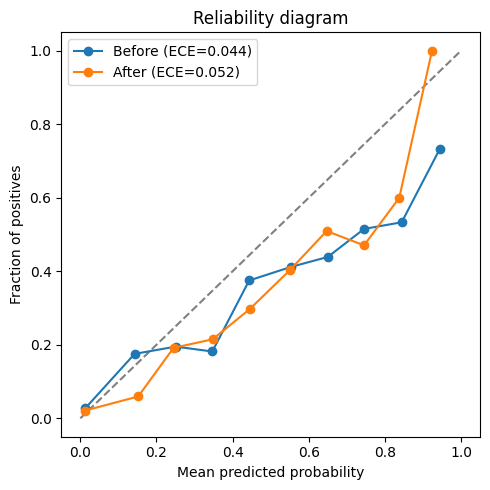

In [8]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

data_cfg = config.get("data", {})
batch_size = int(data_cfg.get("batch_size", 32))
num_workers = int(data_cfg.get("num_workers", 4))
pin_memory = bool(data_cfg.get("pin_memory", True)) and torch.cuda.is_available()

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

def collect_probs_and_logits(model: torch.nn.Module, loader, device: torch.device):
    model.eval()
    probs_list = []
    labels_list = []
    logits_list = []
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].cpu().numpy()
            logits = model(images)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            probs_list.append(probs)
            labels_list.append(labels)
            logits_list.append(logits.detach().cpu())
    probs = np.concatenate(probs_list)
    labels = np.concatenate(labels_list)
    logits = torch.cat(logits_list, dim=0)
    return probs, labels, logits

probs_before, labels_val, logits_val = collect_probs_and_logits(model, val_loader, device)

ts = TemperatureScaling()
ece_before = ts.compute_ece(probs_before, labels_val)
temperature = ts.fit(model, val_loader, device=str(device))

with torch.no_grad():
    scaled_logits = ts(logits_val)
    probs_after = torch.softmax(scaled_logits, dim=1)[:, 1].numpy()

ece_after = ts.compute_ece(probs_after, labels_val)

frac_pos_before, mean_pred_before = calibration_curve(labels_val, probs_before, n_bins=10)
frac_pos_after, mean_pred_after = calibration_curve(labels_val, probs_after, n_bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.plot(mean_pred_before, frac_pos_before, marker="o", label=f"Before (ECE={ece_before:.3f})")
ax.plot(mean_pred_after, frac_pos_after, marker="o", label=f"After (ECE={ece_after:.3f})")
ax.set_title("Reliability diagram")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.legend()
fig.tight_layout()
reliability_path = figure_dir / "reliability_diagram.png"
fig.savefig(reliability_path, dpi=160, bbox_inches="tight")

calibration_summary = {
    "temperature": float(temperature),
    "ece_before": float(ece_before),
    "ece_after": float(ece_after),
    "reliability_plot": str(reliability_path),
}
calibration_path = artifact_dir / "calibration_summary.json"
calibration_path.write_text(json.dumps(calibration_summary, indent=2), encoding="utf-8")

print(f"Saved calibration summary to {calibration_path}")
print(f"Saved reliability diagram to {reliability_path}")
calibration_summary